# 5.Predict_test_LGB
- ノートブック4で保存したLGBモデルでテストデータを予測
- AD範囲を考慮し、AD内のテストデータのみを抽出
- フィルタリング条件は設定変数で指定

---

## ユーザー設定（ここを編集してください）
**以下のセルで目的変数などを指定してください。1.Preparation.ipynb と同じ設定を使用します。**

## ライブラリ読み込み

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import pandas as pd

from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor

import lightgbm as lgb

from rdkit import Chem
from rdkit.Chem import Draw

import optuna
import joblib
import os

from IPython.display import display

from scipy.spatial.distance import cdist
from sklearn.svm import OneClassSVM

c:\Users\kawan\miniforge3\envs\chem_win\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## データ読み込み

### 学習データ読み込み

In [ ]:
# ============================================================
# ユーザー設定: 1.Preparation.ipynb と同じ設定を使用
# ============================================================

# 目的変数の列名（リストで複数指定可能）
TARGET_COLS = ["Emission max (nm)", "Quantum yield"]

# 使用する記述子のタイプ
DESCRIPTOR_TYPE = "rdkit"  # "rdkit" or "mordred_2d" or "mordred_3d" or "fp"

# SMILES列の名前
SMILES_COL = "Chromophore"

# フィルタリング条件（目的変数ごとに [min, max] を指定、None で無効化）
FILTER_CONDITIONS = {
    "Emission max (nm)": [600, None],  # 600nm以上
    "Quantum yield": [0.5, None],      # 50%以上
}

# ============================================================
print(f"目的変数: {TARGET_COLS}")
print(f"記述子タイプ: {DESCRIPTOR_TYPE}")
print(f"フィルタリング条件: {FILTER_CONDITIONS}")

In [2]:
# データ読み込み（設定変数を使用）
dataset = pd.read_csv("../data/dataset_train.csv", index_col=0)
target = dataset[TARGET_COLS]

if DESCRIPTOR_TYPE == "rdkit":
    des = pd.read_csv("outputs/descriptors/rdkit/X_train_rdkit_processed.csv", index_col=0)
elif DESCRIPTOR_TYPE == "mordred_2d":
    des = pd.read_csv("outputs/descriptors/mordred_2d/X_train_mordred_2d_processed.csv", index_col=0)
elif DESCRIPTOR_TYPE == "mordred_3d":
    des = pd.read_csv("outputs/descriptors/mordred_3d/X_train_mordred_3d_processed.csv", index_col=0)
elif DESCRIPTOR_TYPE == "fp":
    des = pd.read_csv("outputs/descriptors/fp/X_train_fp.csv", index_col=0)
else:
    raise ValueError(f"未知の DESCRIPTOR_TYPE: {DESCRIPTOR_TYPE}")

# 目的変数と記述子を結合
dataset_train = target.join(des, how="inner")
print(f"target: {target.shape}, descriptors: {des.shape}, dataset_train: {dataset_train.shape}")

(13132, 2) (13132, 206) (13132, 208)


### テストデータ読み込み

In [3]:
# descriptor_type は学習データ読み込みセルで指定した値を使う（そちらで変更すること）

if descriptor_type == "rdkit":
    des = pd.read_csv("outputs/descriptors/rdkit/X_test_rdkit_processed.csv", index_col=0)
elif descriptor_type == "mordred_2d":
    des = pd.read_csv(
        "outputs/descriptors/mordred_2d/X_test_mordred_2d_processed.csv", index_col=0
    )
elif descriptor_type == "mordred_3d":
    des = pd.read_csv(
        "outputs/descriptors/mordred_3d/X_test_mordred_3d_processed.csv", index_col=0
    )
elif descriptor_type == "fp":
    des = pd.read_csv("outputs/descriptors/fp/X_test_fp.csv", index_col=0)
else:
    raise ValueError(f"未知の descriptor_type: {descriptor_type}")

# 目的変数と記述子を結合
X_test = des
print(des.shape, X_test.shape)

(7104, 206) (7104, 206)


## 予測

### D最適基準（任意）

テスト候補（`X_test`）が多いとき、**記述子空間で情報が広く広がるサブセット**を選び、**似た化合物ばかりが残りにくい**状態にしたい

**D最適基準**では、選択した $n$ 件の記述子行列 $\mathbf{X}$（$n \times p$、行＝サンプル、列＝記述子）について、以下の行列式が**大きくする**組み合わせを探す

$$
\det\left(\mathbf{X}^\top \mathbf{X} + \varepsilon \mathbf{I}\right)
$$

- $\mathbf{X}^\top \mathbf{X}$：記述子の共分散に相当（どの方向に候補が広がっているか）
- $\det(\cdot)$ が大きいほど、記述子の組み合わせとして**多様な候補**が含まれていると解釈される
- $\varepsilon \mathbf{I}$：記述子が多重共線性を持つとき $\mathbf{X}^\top \mathbf{X}$ が特異になりやすいため、コードでは微小な $\varepsilon$ を加えて安定化（実装では `slogdet` で $\log\det$ を評価）

本ノートでは全組み合わせは計算できないため、**ランダムに $n$ 件を選ぶ試行を繰り返し**、上の行列式（の対数）が最大となるサブセットを採用する

**設定**: `use_d_optimal=True` のときだけ上記で `number_of_selecting_samples` 件に間引く。`False` なら `X_test` をそのまま使う。

In [4]:
# True: D最適基準で X_test を number_of_selecting_samples 件に間引く
# False: D最適を行わず X_test をそのまま使う
use_d_optimal = True

number_of_selecting_samples = 3500   # use_d_optimal=True のときの選択数
number_of_random_searches = 500      # D最適探索の反復回数
random_state = 1234

if use_d_optimal:
    if number_of_selecting_samples >= X_test.shape[0]:
        raise ValueError(
            f"number_of_selecting_samples ({number_of_selecting_samples}) は "
            f"X_test の行数 ({X_test.shape[0]}) より小さくしてください"
        )

    # 候補集合内で標準化（D最適計算用）
    autoscaled_X_test = (X_test - X_test.mean()) / X_test.std()
    autoscaled_X_test = autoscaled_X_test.replace([np.inf, -np.inf], np.nan).fillna(0)

    all_indexes = np.arange(X_test.shape[0])
    rng = np.random.default_rng(random_state)

    best_d_optimal_value = -np.inf
    selected_sample_indexes = None
    epsilon = 1e-8  # 特異行列対策

    for _ in range(number_of_random_searches):
        # ランダムサーチで候補を選択
        new_selected_indexes = rng.choice(
            all_indexes, size=number_of_selecting_samples, replace=False
        )
        new_selected_samples = autoscaled_X_test.iloc[new_selected_indexes, :]

        # D最適基準の計算（X'X が特異でも計算できるように微小な正則化を加える）
        # mordred3dの記述子は多重共線性が強いため、εIをX'Xに加える
        xt_x = np.dot(new_selected_samples.T, new_selected_samples)
        xt_x_reg = xt_x + epsilon * np.eye(xt_x.shape[0])
        sign, logdet = np.linalg.slogdet(xt_x_reg)  # 直接巨大な行列式を解くのでなく、sign * exp(logdet) として対数で比較する（D最適はどちらがおおきいかがわかればよいので）
        d_optimal_value = logdet if sign > 0 else -np.inf

        # 初回は必ず採用し、その後は最大値で更新
        if (selected_sample_indexes is None) or (d_optimal_value > best_d_optimal_value):
            best_d_optimal_value = d_optimal_value
            selected_sample_indexes = new_selected_indexes.copy()

    selected_sample_indexes = sorted(selected_sample_indexes.tolist())
    selected_test_tags = X_test.index[selected_sample_indexes]

    print(f"selected: {len(selected_test_tags)} / {X_test.shape[0]}")
    print(f"best log(det(X'X + epsI)): {best_d_optimal_value:.3f}")
else:
    selected_test_tags = X_test.index
    print(f"use_d_optimal=False: X_test をそのまま使用 ({len(selected_test_tags)} 件)")

# 選択済み / 非選択のテストデータを作成
X_test_d_opt = X_test.loc[selected_test_tags].copy()
X_test_remaining = X_test.drop(index=selected_test_tags)

print("X_test_d_opt:", X_test_d_opt.shape)
print("X_test_remaining:", X_test_remaining.shape)

# 必要なら保存
os.makedirs("outputs/result/doe", exist_ok=True)
X_test_d_opt.to_csv("outputs/result/doe/X_test_d_opt.csv")
X_test_remaining.to_csv("outputs/result/doe/X_test_remaining.csv")

selected: 3500 / 7104
best log(det(X'X + epsI)): 738.656
X_test_d_opt: (3500, 206)
X_test_remaining: (3604, 206)


### テストデータ予測

`descriptor_type` に応じて `4.Finalize_LGB` で保存した `artifact_lgb_{descriptor_type}_{emi|qy}.joblib` を読み込む。学習データ・テストデータ・モデルの記述子は一致させること。

In [5]:
def load_artifact_with_fallback(path_candidates):
    """
    保存したモデルセットを読み込む関数
    """
    for p in path_candidates:
        if os.path.exists(p):
            return joblib.load(p), p
    raise FileNotFoundError(f"artifact not found: {path_candidates}")

# データ読み込みセルで指定した descriptor_type に対応するモデルを読み込む
# 4.Finalize_LGB で保存したパス: models/lgb/artifact_lgb_{descriptor_type}_{emi|qy}.joblib
emi_candidates = [f"models/lgb/artifact_lgb_{descriptor_type}_emi.joblib"]
if descriptor_type == "mordred_3d":
    emi_candidates.append("models/lgb/artifact_lgb_mordred_3d.joblib")  # 旧ファイル名

artifact_emi, emi_path = load_artifact_with_fallback(emi_candidates)
artifact_qy, qy_path = load_artifact_with_fallback([
    f"models/lgb/artifact_lgb_{descriptor_type}_qy.joblib",
])

for artifact, path in [(artifact_emi, emi_path), (artifact_qy, qy_path)]:
    if isinstance(artifact, dict):
        saved_desc = artifact.get("descriptor_type")
        if saved_desc is not None and saved_desc != descriptor_type:
            raise ValueError(
                f"{path}: 保存時の descriptor_type={saved_desc!r} が "
                f"現在の {descriptor_type!r} と一致しません"
            )

model_emi = artifact_emi["model"] if isinstance(artifact_emi, dict) else artifact_emi
model_qy = artifact_qy["model"] if isinstance(artifact_qy, dict) else artifact_qy

feature_columns_emi = (
    artifact_emi["feature_columns"]
    if isinstance(artifact_emi, dict)
    else dataset_train.drop(columns=["Emission max (nm)", "Quantum yield"]).columns.tolist()
)
feature_columns_qy = (
    artifact_qy["feature_columns"]
    if isinstance(artifact_qy, dict)
    else dataset_train.drop(columns=["Emission max (nm)", "Quantum yield"]).columns.tolist()
)

# D最適セルで作成した X_test_d_opt を予測対象に使う（use_d_optimal=False のときは全件）
X_test_for_pred = X_test_d_opt

def _check_feature_columns(X: pd.DataFrame, columns: list[str], label: str) -> None:
    missing = [c for c in columns if c not in X.columns]
    if missing:
        raise ValueError(
            f"{label}: テストデータに学習時の記述子が {len(missing)} 件ありません "
            f"(descriptor_type={descriptor_type!r})。例: {missing[:3]}"
        )

_check_feature_columns(X_test_for_pred, feature_columns_emi, "emi")
_check_feature_columns(X_test_for_pred, feature_columns_qy, "qy")

# 学習時の列順に合わせる
X_test_emi = X_test_for_pred.reindex(columns=feature_columns_emi)
X_test_qy = X_test_for_pred.reindex(columns=feature_columns_qy)

# 予測
y_pred_emi = model_emi.predict(X_test_emi)
y_pred_qy = model_qy.predict(X_test_qy)

# 予測結果を統合（qyは0-1スケール想定）
pred_df = pd.DataFrame(
    {
        "emi_pred": y_pred_emi,
        "qy_pred": y_pred_qy,
    },
    index=X_test_for_pred.index,
)

print("emi model:", emi_path)
print("qy  model:", qy_path)
print("predict rows:", pred_df.shape[0])
pred_df.head()

c:\Users\kawan\miniforge3\envs\chem_win\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


emi model: models/lgb/artifact_lgb_rdkit_emi.joblib
qy  model: models/lgb/artifact_lgb_rdkit_qy.joblib
predict rows: 3500


c:\Users\kawan\miniforge3\envs\chem_win\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,emi_pred,qy_pred
Tag,,
6,448.192377,0.506724
7,448.192377,0.506724
12,462.827696,0.541541
16,489.495232,0.423348
17,489.495232,0.423348


## AD判定
学習データの分布から離れている材料は除外する

In [6]:
# ADモデル用に標準化（emissionモデルのx_scalerを再利用）
X_train_ad = dataset_train.drop(columns=["Emission max (nm)", "Quantum yield"])
X_train_ad = X_train_ad.reindex(columns=feature_columns_emi)
X_test_ad = X_test_for_pred.reindex(columns=feature_columns_emi)

# model_emi が TransformedTargetRegressor + Pipeline の想定
ad_scaler = None
if hasattr(model_emi, "regressor_") and hasattr(model_emi.regressor_, "named_steps"):
    ad_scaler = model_emi.regressor_.named_steps.get("x_scaler", None)

# 念のためのフォールバック（構造が異なる場合）
if ad_scaler is None:
    ad_scaler = StandardScaler()
    ad_scaler.fit(X_train_ad.values)

autoscaled_X_train = ad_scaler.transform(X_train_ad.values)
autoscaled_X_test = ad_scaler.transform(X_test_ad.values)

print("autoscaled_X_train:", autoscaled_X_train.shape)
print("autoscaled_X_test :", autoscaled_X_test.shape)

autoscaled_X_train: (13132, 206)
autoscaled_X_test : (3500, 206)


c:\Users\kawan\miniforge3\envs\chem_win\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\kawan\miniforge3\envs\chem_win\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [7]:
def gamma_optimization_with_variance(x, gammas):
    """
    DataFrame型もしくはarray型のxにおいて、カーネル関数におけるグラム行列の分散を最大化することにより、yを最適化する関数

    Parameters
    -----------------------------------
    x : pandas.DataFrame or numpy.array
    gammas : list

    Returns
    -------
    optimized gamma : scaler

    """

    print('カーネル関数においてグラム行列の分散を最大化することによりγの最適化')

    variance_of_gamma_matrix = []

    for index, ocsvm_gamma in enumerate(gammas):
        # print(index + 1, '/', len(gammas))
        gram_matrix = np.exp(-ocsvm_gamma * cdist(x, x, metric='sqeuclidean'))
        variance_of_gamma_matrix.append(gram_matrix.var(ddof=1))

    return gammas[variance_of_gamma_matrix.index(max(variance_of_gamma_matrix))]

In [8]:
# OCSVMによるAD
# OCSVMにおけるnu, nu=0.317(σ), nu=0.045(2σ), nu=0.003(3σ)など選択でき、学習時の境界の形・きつさを決めるハイパラ
# 学習データのうち、最大でnuだけを境界の外にしても良いという上限を与える（サポートベクタ比の下限）
# nuの値が大きくなるとADは狭まるが誤差は小さくなり、nuが小さくなるとADは広がるが、誤差は大きくなる
# nu=0.317ならば、約68%のデータが含まれる範囲（±1σ相当）を定義するイメージ、ただし直感的なイメージであって、厳密な対応ではない。
ocsvm_nu = 0.003

# γの候補
ocsvm_gammas = 2 ** np.arange(-20, 11, dtype=float)

# グラム行列の分散を最大化することによるγの候補、最も情報量の多いγを選ぶことができる
optimal_ocsvm_gamma = gamma_optimization_with_variance(autoscaled_X_train, ocsvm_gammas)

print('最適化されたgamma(OCSVM) :', optimal_ocsvm_gamma)

カーネル関数においてグラム行列の分散を最大化することによりγの最適化
最適化されたgamma(OCSVM) : 0.001953125


In [9]:
# ADモデル構築
ocsvm_model = OneClassSVM(kernel="rbf", gamma=optimal_ocsvm_gamma, nu=ocsvm_nu)
ocsvm_model.fit(autoscaled_X_train)

# density
data_density_train = ocsvm_model.decision_function(autoscaled_X_train).ravel()
data_density_test  = ocsvm_model.decision_function(autoscaled_X_test).ravel()

# しきい値（trainの下位25%を外）
threshold_percentile = 25
threshold = np.percentile(data_density_train, threshold_percentile)

in_ad_ocsvm = data_density_test >= threshold

print(f"OCSVM-AD threshold (p{threshold_percentile}): {threshold:.6f}")
print(f"OCSVM-AD in: {in_ad_ocsvm.sum()} / {len(in_ad_ocsvm)}")

OCSVM-AD threshold (p25): 0.690492
OCSVM-AD in: 2623 / 3500


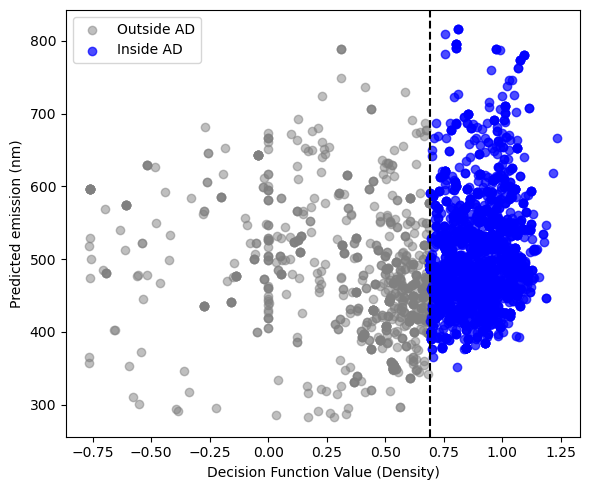

In [10]:
# density ≥ threshold のインデックス
in_ad_index = data_density_test >= threshold
out_ad_index = data_density_test < threshold

plt.figure(figsize=(6, 5))

plt.scatter(
    data_density_test[out_ad_index],
    pred_df["emi_pred"].iloc[out_ad_index],
    color="gray", alpha=0.5, label="Outside AD"
)

plt.scatter(
    data_density_test[in_ad_index],
    pred_df["emi_pred"].iloc[in_ad_index],
    color="blue", alpha=0.7, label="Inside AD"
)

plt.axvline(x=threshold, color="black", linestyle="--")
plt.xlabel("Decision Function Value (Density)")
plt.ylabel("Predicted emission (nm)")
plt.legend()
plt.tight_layout()
plt.show()

## Filtering
目的のspecを満たす材料のみ（今回は長波長発光かつ高PLQY）を抽出する

In [11]:
# AD内かつ、発光波長 >= 600 nm、量子収率 >= 50% (0.5) を抽出
# Quantum yield は 0-1 スケール想定

result_df = pred_df.copy()
result_df["in_ad"] = in_ad_ocsvm

selected_candidates = result_df[
    (result_df["in_ad"])
    & (result_df["emi_pred"] >= 600)
    & (result_df["qy_pred"] >= 0.5)
].sort_values(["emi_pred", "qy_pred"], ascending=False)

print("selected candidates:", selected_candidates.shape[0])
selected_candidates.head(20)

selected candidates: 23


,emi_pred,qy_pred,in_ad
Tag,,,
17606,686.032349,0.501191,True
17908,679.520016,0.821478,True
17912,679.520016,0.821478,True
17916,679.520016,0.821478,True
6311,614.128869,0.522631,True
6317,614.128869,0.522631,True
17899,612.634515,0.834762,True
17903,612.634515,0.834762,True
17907,612.634515,0.834762,True


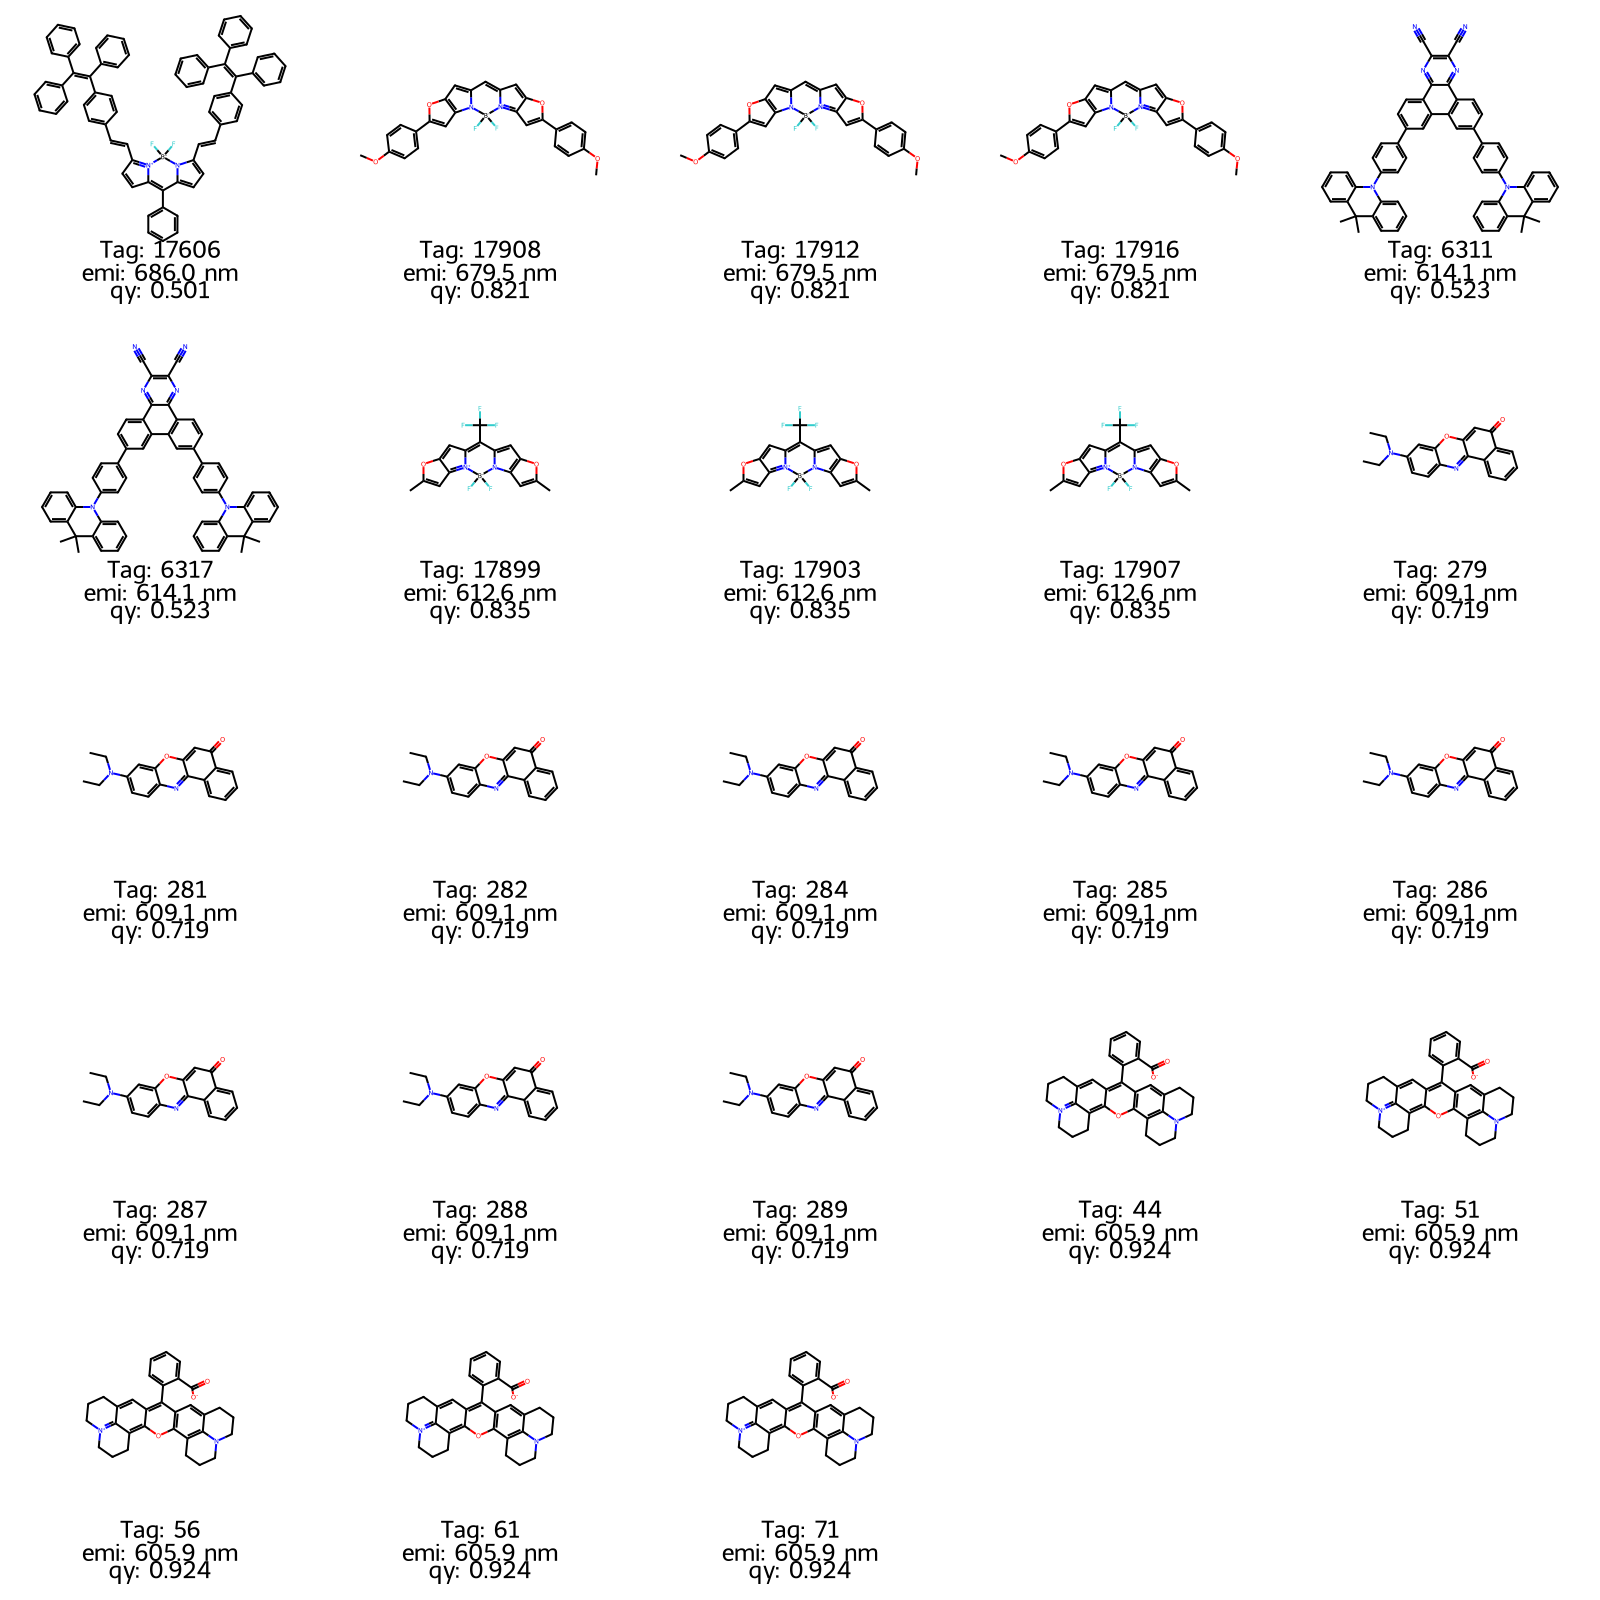

In [ ]:
# selected_candidates の全件を RDKit でグリッド表示（legendにemi/qy付き）

tags = selected_candidates.index.tolist()

# train/test の Chromophore を結合
dataset_test = pd.read_csv("../data/dataset_test.csv", index_col=0)
chromophore = pd.concat(
    [
        dataset["Chromophore"],
        dataset_test["Chromophore"],
    ]
)
chromophore = chromophore[~chromophore.index.duplicated(keep="first")]

smiles = chromophore.loc[tags]
mols = [Chem.MolFromSmiles(str(s)) for s in smiles]

legends = [
    f"Tag: {tag}\nemi: {selected_candidates.loc[tag, 'emi_pred']:.1f} nm\nqy: {selected_candidates.loc[tag, 'qy_pred']:.3f}"
    for tag in tags
]

# RDKitの描画オプションを先に設定（バージョン差異対応）
# Qiita記事のやり方で legend サイズを調整
options = Draw.MolDrawOptions()
options.legendFontSize = 28   # まずは24前後が見やすい
options.legendFraction = 0.22 # 複数行legend用に領域を広めに確保

display(
    Draw.MolsToGridImage(
        mols,
        molsPerRow=5,
        subImgSize=(320, 320),
        legends=legends,
        drawOptions=options
    )
)

- 同じ材料が重複して選ばれているのは、元のデータセットは溶媒の列もあるため、材料は同じだが溶媒が違う条件を抽出してきているため、
- 極性の低い溶媒（トルエンやヘキサン）で600nm以上の発光波長であれば、specは十分達成できるので問題なし。

In [13]:
# 選ばれた材料を保存
selected_candidates.to_csv("outputs/result/doe/selected_candidates.csv")